In [ ]:
pip install yfinance pandas numpy scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
# --- 1. Arsitektur IT2-ANFIS ---
class IT2_ANFIS:
    def __init__(self, n_inputs, n_mf):
        self.n_inputs = n_inputs
        self.n_mf = n_mf
        self.n_rules = n_mf ** n_inputs
        self.n_ant_params = n_inputs * n_mf * 3
        self.n_cons_params = self.n_rules * (n_inputs + 1)
        self.total_params = self.n_ant_params + self.n_cons_params

    def forward(self, X, params):
        ant_params = params[:self.n_ant_params].reshape(self.n_inputs, self.n_mf, 3)
        cons_params = params[self.n_ant_params:].reshape(self.n_rules, self.n_inputs + 1)

        N = X.shape[0]
        mu_low = np.zeros((N, self.n_inputs, self.n_mf))
        mu_up = np.zeros((N, self.n_inputs, self.n_mf))

        for i in range(self.n_inputs):
            for j in range(self.n_mf):
                c, s1, s2 = ant_params[i, j]
                s_min, s_max = abs(min(s1, s2)), abs(max(s1, s2))
                mu_low[:, i, j] = np.exp(-0.5 * ((X[:, i] - c) / (s_min + 1e-9))**2)
                mu_up[:, i, j] = np.exp(-0.5 * ((X[:, i] - c) / (s_max + 1e-9))**2)

        w_low = np.ones((N, self.n_rules))
        w_up = np.ones((N, self.n_rules))

        grid = np.meshgrid(*[np.arange(self.n_mf) for _ in range(self.n_inputs)])
        rule_idx = np.stack(grid, axis=-1).reshape(-1, self.n_inputs)

        for k in range(self.n_rules):
            for i in range(self.n_inputs):
                mf_idx = rule_idx[k, i]
                w_low[:, k] *= mu_low[:, i, mf_idx]
                w_up[:, k] *= mu_up[:, i, mf_idx]

        X_with_bias = np.hstack([X, np.ones((N, 1))])
        f = X_with_bias @ cons_params.T

        # --- Type Reduction: Karnik-Mendel (KM) ---
        y_pred = np.zeros(N)

        for idx in range(N):
            f_row = f[idx]
            w_l_row = w_low[idx]
            w_u_row = w_up[idx]

            # 1. Sort f (consequent) in ascending order
            sort_idx = np.argsort(f_row)
            f_s = f_row[sort_idx]
            w_l_s = w_l_row[sort_idx]
            w_u_s = w_u_row[sort_idx]

            # Initial weights for calculation
            w_init = (w_l_s + w_u_s) / 2

            # --- Menghitung y_left (y_l) ---
            y_prime = np.sum(f_s * w_init) / (np.sum(w_init) + 1e-9)
            for _ in range(15): # Max iteration safeguard to avoid infinite loop
                L = np.searchsorted(f_s, y_prime) - 1
                L = max(0, min(L, len(f_s) - 2)) # Ensure valid switch point index

                # Bobot KM untuk y_left: w_up untuk kiri, w_low untuk kanan
                w_temp = np.concatenate([w_u_s[:L+1], w_l_s[L+1:]])
                y_new = np.sum(f_s * w_temp) / (np.sum(w_temp) + 1e-9)

                if abs(y_new - y_prime) < 1e-6:
                    break
                y_prime = y_new
            y_left = y_prime

            # --- Menghitung y_right (y_r) ---
            y_prime = np.sum(f_s * w_init) / (np.sum(w_init) + 1e-9)
            for _ in range(15):
                R = np.searchsorted(f_s, y_prime) - 1
                R = max(0, min(R, len(f_s) - 2)) # Ensure valid switch point index

                # Bobot KM untuk y_right: w_low untuk kiri, w_up untuk kanan
                w_temp = np.concatenate([w_l_s[:R+1], w_u_s[R+1:]])
                y_new = np.sum(f_s * w_temp) / (np.sum(w_temp) + 1e-9)

                if abs(y_new - y_prime) < 1e-6:
                    break
                y_prime = y_new
            y_right = y_prime

            # De-fuzzification akhir
            y_pred[idx] = (y_left + y_right) / 2

        return y_pred

# --- 2. Fungsi Evaluasi ---
def calculate_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def calculate_accuracy(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9)))
    return max(0, (1 - mape) * 100)

# --- 3. Optimasi PSO ---
def pso_optimize(model, X, y, n_particles=20, iterations=30):
    dim = model.total_params
    pos = np.random.uniform(-1, 1, (n_particles, dim))
    vel = np.zeros((n_particles, dim))
    pbest_pos = pos.copy()
    pbest_fit = np.array([calculate_rmse(y, model.forward(X, p)) for p in pos])
    gbest_pos = pbest_pos[np.argmin(pbest_fit)].copy()
    gbest_fit = np.min(pbest_fit)

    w, c1, c2 = 0.5, 1.5, 1.5
    for it in range(iterations):
        for i in range(n_particles):
            r1, r2 = np.random.rand(dim), np.random.rand(dim)
            vel[i] = w*vel[i] + c1*r1*(pbest_pos[i] - pos[i]) + c2*r2*(gbest_pos - pos[i])
            pos[i] += vel[i]
            fit = calculate_rmse(y, model.forward(X, pos[i]))
            if fit < pbest_fit[i]:
                pbest_fit[i], pbest_pos[i] = fit, pos[i].copy()
        if np.min(pbest_fit) < gbest_fit:
            gbest_fit = np.min(pbest_fit)
            gbest_pos = pbest_pos[np.argmin(pbest_fit)].copy()
        print(f"Iterasi {it+1}/{iterations} - RMSE: {gbest_fit:.6f}")
    return gbest_pos

In [ ]:
# --- 4. Data Preparation (Yahoo Finance) ---
def load_bitcoin_data(lookback=3):
    print("Mengambil data Bitcoin...")
    df = yf.download('BTC-USD', start='2021-01-01', interval='1d')
    data = df['Close'].values.reshape(-1, 1)

    # Normalisasi ke range [0, 1]
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    # Membuat dataset Time Series (X = harga t-3, t-2, t-1; y = harga t)
    X, y = [], []
    for i in range(len(scaled_data) - lookback):
        X.append(scaled_data[i : i + lookback, 0])
        y.append(scaled_data[i + lookback, 0])

    X, y = np.array(X), np.array(y)

    # Split Data: 80% Train, 20% Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test, scaler

/tmp/ipykernel_682/4135920782.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2021-01-01', end='2025-12-31', interval='1d')
[*********************100%***********************]  1 of 1 completed

Mengambil data historis Bitcoin...

=== Statistik Deskriptif BTC-USD (2021 - 2025) ===
Total Baris Data (N)  : 1825 hari
Harga Minimum         : $15,787.28
Harga Maksimum        : $124,752.53
Rata-rata (Mean)      : $54,408.23
Simpangan Baku (Std)  : $29,461.70



/tmp/ipykernel_682/4135920782.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"Harga Minimum         : ${float(df['Close'].min()):,.2f}")
/tmp/ipykernel_682/4135920782.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"Harga Maksimum        : ${float(df['Close'].max()):,.2f}")
/tmp/ipykernel_682/4135920782.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"Rata-rata (Mean)      : ${float(df['Close'].mean()):,.2f}")
/tmp/ipykernel_682/4135920782.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"Simpangan Baku (Std)  : ${float(df['Close'].std()):,.2f}")



Grafik berhasil disimpan dengan nama 'Grafik_Historis_BTC.png'


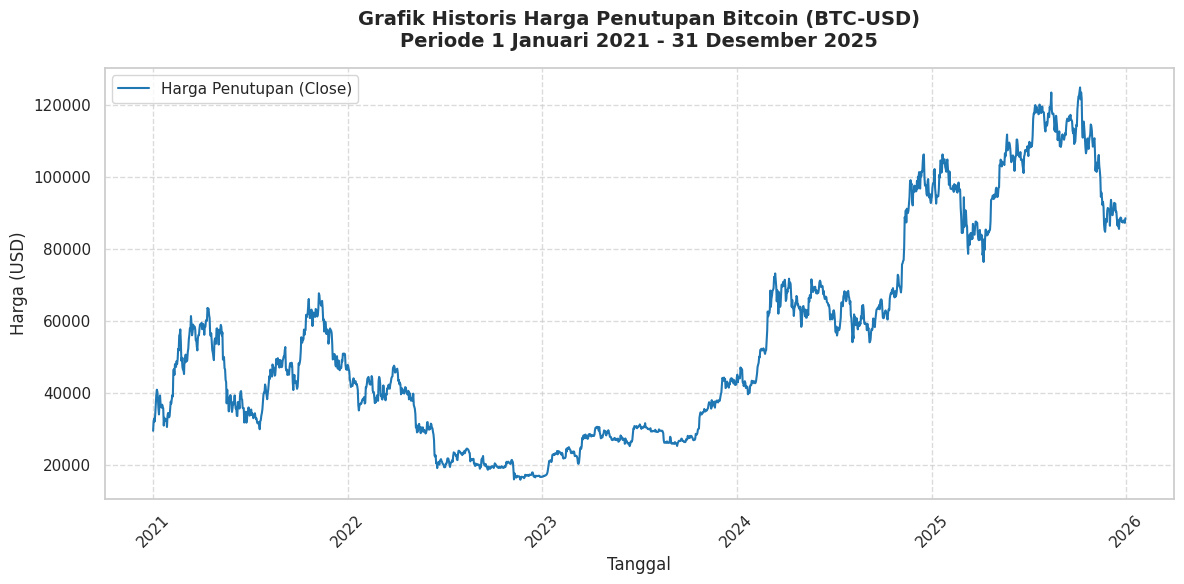

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def visualize_historical_data():
    print("Mengambil data historis Bitcoin...")
    # Mengambil data dari rentang waktu yang kamu sebutkan (Jan 2021 - Des 2025)
    df = yf.download('BTC-USD', start='2021-01-01', end='2025-12-31', interval='1d')

    # Memastikan tidak ada nilai yang kosong (Drop NaN jika ada)
    df = df.dropna()

    # ==========================================
    # 1. EKSTRAKSI STATISTIK DESKRIPTIF
    # ==========================================
    print("\n=== Statistik Deskriptif BTC-USD (2021 - 2025) ===")
    print(f"Total Baris Data (N)  : {len(df)} hari")
    # Jika menggunakan pandas versi baru, hasil yf.download berupa MultiIndex column,
    # kita ambil nilai skalar (float) menggunakan float() agar format rapi
    print(f"Harga Minimum         : ${float(df['Close'].min()):,.2f}")
    print(f"Harga Maksimum        : ${float(df['Close'].max()):,.2f}")
    print(f"Rata-rata (Mean)      : ${float(df['Close'].mean()):,.2f}")
    print(f"Simpangan Baku (Std)  : ${float(df['Close'].std()):,.2f}")
    print("==================================================")

    # ==========================================
    # 2. VISUALISASI GRAFIK
    # ==========================================
    # Menggunakan tema Seaborn agar grafik terlihat profesional untuk skripsi
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))

    # Memplot garis harga penutupan
    plt.plot(df.index, df['Close'], color='#1f77b4', linewidth=1.5, label='Harga Penutupan (Close)')

    # Kustomisasi judul dan label sumbu
    plt.title('Grafik Historis Harga Penutupan Bitcoin (BTC-USD)\nPeriode 1 Januari 2021 - 31 Desember 2025',
              fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Tanggal', fontsize=12)
    plt.ylabel('Harga (USD)', fontsize=12)

    # Menambahkan legenda dan grid
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Merotasi teks tanggal di sumbu X agar tidak bertumpuk
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Menyimpan grafik dalam resolusi tinggi (300 DPI) untuk di-insert ke MS Word
    plt.savefig('Grafik_Historis_BTC.png', dpi=300, bbox_inches='tight')
    print("\nGrafik berhasil disimpan dengan nama 'Grafik_Historis_BTC.png'")

    # Menampilkan grafik di layar
    plt.show()

# Menjalankan fungsi
visualize_historical_data()

In [ ]:
X_train, X_test, y_train, y_test, scaler = load_bitcoin_data(7)

/tmp/ipykernel_682/538342751.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2021-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed

Mengambil data Bitcoin...


In [ ]:
# Create a dictionary for training data
train_data_dict = {}
for i in range(X_train.shape[1]):
    train_data_dict[f'input_feature_{i+1}'] = X_train[:, i]
train_data_dict['target_value'] = y_train

train_df = pd.DataFrame(train_data_dict)
print("Training Data DataFrame (first 5 rows):")
display(train_df.head())

# Create a dictionary for testing data
test_data_dict = {}
for i in range(X_test.shape[1]):
    test_data_dict[f'input_feature_{i+1}'] = X_test[:, i]
test_data_dict['target_value'] = y_test

test_df = pd.DataFrame(test_data_dict)
print("\nTesting Data DataFrame (first 5 rows):")
display(test_df.tail())

Training Data DataFrame (first 5 rows):


,input_feature_1,input_feature_2,input_feature_3,input_feature_4,input_feature_5,input_feature_6,input_feature_7,target_value
0,0.124690,0.149956,0.155965,0.148530,0.167073,0.193062,0.216434,0.229526
1,0.149956,0.155965,0.148530,0.167073,0.193062,0.216434,0.229526,0.224542
2,0.155965,0.148530,0.167073,0.193062,0.216434,0.229526,0.224542,0.207123
3,0.148530,0.167073,0.193062,0.216434,0.229526,0.224542,0.207123,0.181520
4,0.167073,0.193062,0.216434,0.229526,0.224542,0.207123,0.181520,0.166435



Testing Data DataFrame (first 5 rows):


,input_feature_1,input_feature_2,input_feature_3,input_feature_4,input_feature_5,input_feature_6,input_feature_7,target_value
380,0.469359,0.472657,0.488180,0.487059,0.515333,0.507832,0.513747,0.524862
381,0.472657,0.488180,0.487059,0.515333,0.507832,0.513747,0.524862,0.525553
382,0.488180,0.487059,0.515333,0.507832,0.513747,0.524862,0.525553,0.504437
383,0.487059,0.515333,0.507832,0.513747,0.524862,0.525553,0.504437,0.538680
384,0.515333,0.507832,0.513747,0.524862,0.525553,0.504437,0.538680,0.538115


Mengambil data Bitcoin...


/tmp/ipykernel_3924/220328788.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2021-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed


Melatih model dengan 1524 data...
Iterasi 1/100 - RMSE: 0.054865
Iterasi 2/100 - RMSE: 0.054865
Iterasi 3/100 - RMSE: 0.054751
Iterasi 4/100 - RMSE: 0.038003
Iterasi 5/100 - RMSE: 0.038003
Iterasi 6/100 - RMSE: 0.038003
Iterasi 7/100 - RMSE: 0.038003
Iterasi 8/100 - RMSE: 0.034475
Iterasi 9/100 - RMSE: 0.034475
Iterasi 10/100 - RMSE: 0.030950
Iterasi 11/100 - RMSE: 0.030950
Iterasi 12/100 - RMSE: 0.030950
Iterasi 13/100 - RMSE: 0.030950
Iterasi 14/100 - RMSE: 0.029637
Iterasi 15/100 - RMSE: 0.027911
Iterasi 16/100 - RMSE: 0.026306
Iterasi 17/100 - RMSE: 0.023745
Iterasi 18/100 - RMSE: 0.023745
Iterasi 19/100 - RMSE: 0.023745
Iterasi 20/100 - RMSE: 0.022989
Iterasi 21/100 - RMSE: 0.022989
Iterasi 22/100 - RMSE: 0.022914
Iterasi 23/100 - RMSE: 0.022914
Iterasi 24/100 - RMSE: 0.022260
Iterasi 25/100 - RMSE: 0.022260
Iterasi 26/100 - RMSE: 0.022012
Iterasi 27/100 - RMSE: 0.022012
Iterasi 28/100 - RMSE: 0.022012
Iterasi 29/100 - RMSE: 0.022012
Iterasi 30/100 - RMSE: 0.022012
Iterasi 31/100 

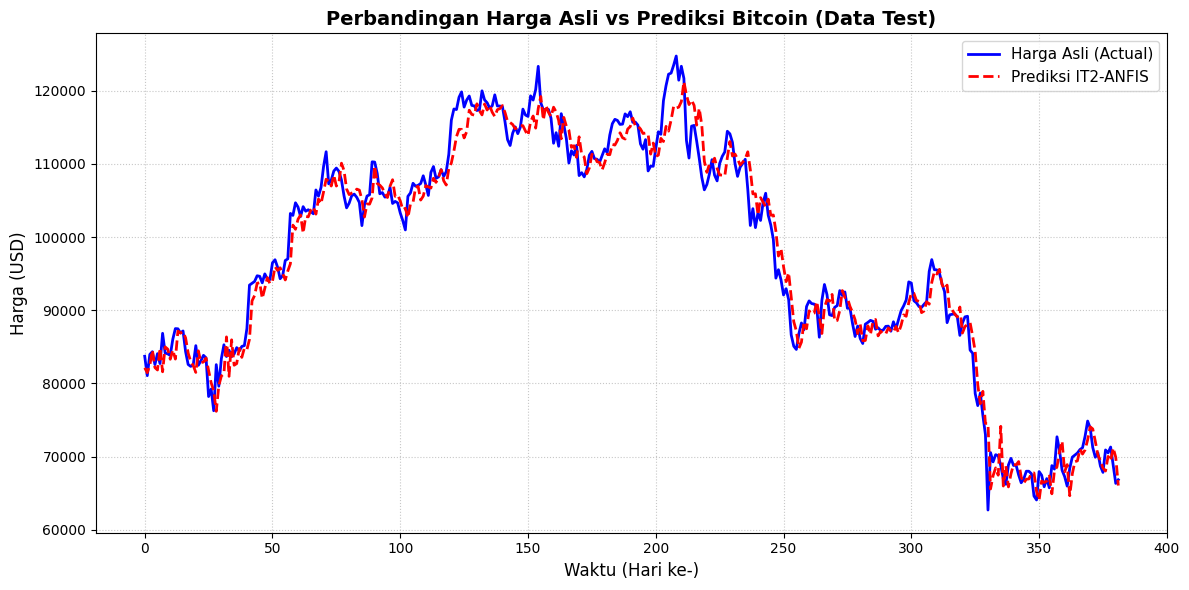


MEMULAI PREDIKSI MASA DEPAN
Berhasil memprediksi 30 hari ke depan!
Prediksi harga hari ke-1: $67101.77
Prediksi harga hari ke-30: $62451.33


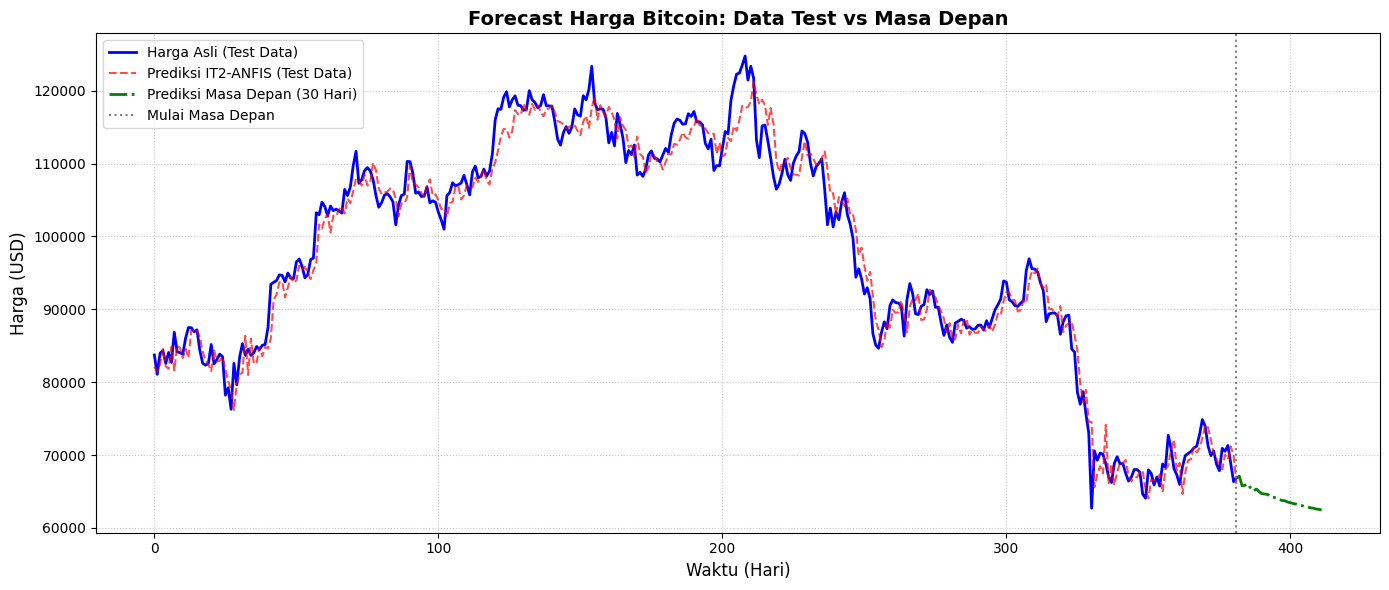

In [ ]:
# --- 5. Main Execution ---
if __name__ == "__main__":
    LOOKBACK = 7 # Menggunakan 7 hari sebelumnya untuk prediksi
    X_train, X_test, y_train, y_test, scaler = load_bitcoin_data(lookback=LOOKBACK)

    # Inisialisasi Model (3 input, 2 MF per input)
    model = IT2_ANFIS(n_inputs=LOOKBACK, n_mf=2)

    print(f"Melatih model dengan {X_train.shape[0]} data...")
    best_params = pso_optimize(model, X_train, y_train, n_particles=50, iterations=100)

    # Prediksi pada Data Test
    y_pred_scaled = model.forward(X_test, best_params)

    # Denormalisasi untuk melihat harga asli
    y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_real = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # Metrik Akhir
    rmse = calculate_rmse(y_test_real, y_pred_real)
    accuracy = calculate_accuracy(y_test_real, y_pred_real)

    print("\n" + "="*30)
    print("HASIL PREDIKSI BITCOIN (DATA TEST)")
    print(f"RMSE    : ${rmse:.2f}")
    print(f"Akurasi : {accuracy:.2f} %")
    print("="*30)

    # Contoh tampilan 5 prediksi terakhir
    print("\n5 Prediksi Terakhir vs Harga Asli:")
    for i in range(-5, 0):
        print(f"Asli: ${y_test_real[i]:.2f} | Prediksi: ${y_pred_real[i]:.2f}")
    # --- 6. Visualisasi Hasil ---
    print("\nMenampilkan grafik visualisasi...")
    plt.figure(figsize=(12, 6))

    # Plot harga asli (warna biru, garis tegas)
    plt.plot(y_test_real, label='Harga Asli (Actual)', color='blue', linewidth=2)

    # Plot harga prediksi (warna merah, garis putus-putus)
    plt.plot(y_pred_real, label='Prediksi IT2-ANFIS', color='red', linestyle='--', linewidth=2)

    # Konfigurasi tampilan grafik
    plt.title('Perbandingan Harga Asli vs Prediksi Bitcoin (Data Test)', fontsize=14, fontweight='bold')
    plt.xlabel('Waktu (Hari ke-)', fontsize=12)
    plt.ylabel('Harga (USD)', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()

    # Tampilkan grafik
    plt.show()

    # --- 7. Prediksi Masa Depan (Out-of-Sample Forecasting) ---
    print("\n" + "="*30)
    print("MEMULAI PREDIKSI MASA DEPAN")
    print("="*30)

    future_days = 30 # Ubah angka ini untuk menentukan berapa hari ke depan (misal 30 untuk 1 bulan)

    # 1. Menyiapkan pijakan awal (window terakhir dari data)
    # X_test[-1] berisi [t-3, t-2, t-1], dan y_test[-1] adalah harga di waktu t.
    # Maka, window awal untuk memprediksi t+1 adalah [t-2, t-1, t]
    current_window = np.append(X_test[-1][1:], y_test[-1])

    future_preds_scaled = []

    # 2. Looping peramalan rekursif
    for i in range(future_days):
        # Format input agar sesuai dengan model: shape (1, LOOKBACK)
        X_input = current_window.reshape(1, LOOKBACK)

        # Prediksi 1 hari ke depan
        next_pred = model.forward(X_input, best_params)[0]
        future_preds_scaled.append(next_pred)

        # Geser window: buang data paling lama (index 0), masukkan hasil prediksi baru di akhir
        current_window = np.append(current_window[1:], next_pred)

    # 3. Denormalisasi hasil prediksi ke harga USD asli
    future_preds_real = scaler.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1)).flatten()

    print(f"Berhasil memprediksi {future_days} hari ke depan!")
    print(f"Prediksi harga hari ke-1: ${future_preds_real[0]:.2f}")
    print(f"Prediksi harga hari ke-{future_days}: ${future_preds_real[-1]:.2f}")

    # --- 8. Visualisasi Masa Depan ---
    plt.figure(figsize=(14, 6))

    # Membuat sumbu X untuk data test dan data masa depan
    x_test_axis = np.arange(len(y_test_real))
    x_future_axis = np.arange(len(y_test_real), len(y_test_real) + future_days)

    # Plot data test (sebagai konteks historis)
    plt.plot(x_test_axis, y_test_real, label='Harga Asli (Test Data)', color='blue', linewidth=2)
    plt.plot(x_test_axis, y_pred_real, label='Prediksi IT2-ANFIS (Test Data)', color='red', linestyle='--', alpha=0.7)

    # Plot prediksi masa depan
    # Kita sambungkan titik terakhir y_test_real dengan titik pertama future_preds_real agar garisnya tidak terputus
    x_future_connected = np.insert(x_future_axis, 0, x_test_axis[-1])
    y_future_connected = np.insert(future_preds_real, 0, y_test_real[-1])

    plt.plot(x_future_connected, y_future_connected, label=f'Prediksi Masa Depan ({future_days} Hari)', color='green', linewidth=2, linestyle='-.')

    plt.title('Forecast Harga Bitcoin: Data Test vs Masa Depan', fontsize=14, fontweight='bold')
    plt.xlabel('Waktu (Hari)', fontsize=12)
    plt.ylabel('Harga (USD)', fontsize=12)

    # Menambahkan garis vertikal penanda mulainya masa depan
    plt.axvline(x=len(y_test_real)-1, color='gray', linestyle=':', label='Mulai Masa Depan')

    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()